In [55]:
import sys
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm
import copy
import CoolProp.CoolProp as CP

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator.datamodels_nba import (
    FrostEvaporatorParameters, 
    FrostEvaporatorInputs, 
    FrostEvaporatorState,
    AirInputs,
    RefrigerantInputs,
)

from frost_evaporator.frost import FrostModel
from frost_evaporator.air import AirModel
from frost_evaporator.refrigerant import RefrigerantModel, propane_RP
from frost_evaporator.heat_mass_transfer import HeatMassTransferModel
from frost_evaporator.thermo import ThermoModel



#############################################################################
# Define Parameters
#############################################################################

AIR_LAYERS = 2

params = FrostEvaporatorParameters(
    # General
    time_step=20.0,  # [s]
    gravity=9.81,  # [m/s^2]

    # Correlations Choices
    frost_density_correlation_choice="da_silva_paper",
    frost_thickness_correlation_choice="jonas_diss",
    frost_conductivity_correlation_choice="da_silva_paper",
    nusselt_correlation_choice="N2",

    # Fan and Air Side Pressure Loss Parameters



    correction_factor_h_conv_air=0.62,
    correction_factor_surface_density=0.87,
    correction_factor_eta_fin=0.77,
    correction_factor_k_frost=1.04,
    correction_factor_pressure_loss=1.00,
    correction_factor_betta_air=0.87,


    # Geometrie Parameters
    fin_pitch=0.0025,  # [m] Calculated: 4 fins/cm = 0.25 cm pitch = 2.5 mm
    fin_height=0.152,  # [m] Paper: Height = 152 mm
    fin_length=0.045 / AIR_LAYERS,  # [m] Paper: Depth (air flow length) = 45 mm
    fin_thickness=0.0002,  # [m] Paper: 0.2 mm thickness
    fin_amount=128,  # [-] Calculated: Width (320mm) / Pitch (2.5mm) = 128 fins
    fin_thermal_conductivity=200.0,  # [W/mK] Paper: "Aluminum alloy" (Standard value usually ~200-220)
    tube_outer_diameter=0.010,  # [m] Paper: 10 mm Outer Diameter
    tube_inner_diameter=0.008,  # [m] Paper: 1 mm wall thickness -> ID = 10 - 2*1 = 8 mm
    tube_layers=2 / AIR_LAYERS,  # [-] Paper: "Two rows"
    tubes_per_layer=6,  # [-] Paper: "Six tubes per row"
    tube_thermal_conductivity=400, # [W/mK] Paper: Copper tubes (Standard value ~385-400)

    alpha_0=4300.0,  # [W/m^2K] - 4300 for propane, used for two phase htc (VDI H2 Tab. 1)
)


#############################################################################
# 2. Define the Simulation Function
#############################################################################
def run_simulation_case(case_name, T_air_C, RH_in, T_surf_C, duration_mins, color, dt_override):
    """
    Runs the multi-layer simulation for a specific set of boundary conditions.
    Now accepts dt_override to change time step dynamically.
    """
    
    # --- UPDATE TIME STEP ---
    params.time_step = dt_override
    
    print(f"--- Starting: {case_name} (dt={dt_override}s) ---")
    print(f"Inputs: T_air={T_air_C}°C, RH={RH_in*100}%, T_surf={T_surf_C}°C, Time={duration_mins}min")

    # --- Setup Inputs ---
    refrigerant_inputs = RefrigerantInputs(h_in=0.0, p_eva=0.0, m_dot=0.0)

    T_air_in_val = 273.15 + T_air_C
    p_air_in_val = 101325.0
    R_air_in_val = RH_in

    # Calculate W_in
    W_air_in_calculated = CP.HAPropsSI('W', 'T', T_air_in_val, 'P', p_air_in_val, 'R', R_air_in_val)

    global_air_inputs = AirInputs(
        T_in = T_air_in_val,
        p_in = p_air_in_val,
        W_in = W_air_in_calculated 
    )

    global_inputs = FrostEvaporatorInputs(
        air_inputs=global_air_inputs,
        refrigerant_inputs=refrigerant_inputs
    )

    # --- Instantiate Models (Fresh for each run) ---
    frost_model = FrostModel(params)
    air_model   = AirModel(params)
    hmt_model   = HeatMassTransferModel(params)
    thermo_model = ThermoModel(params)
    # refrigerant_model not strictly needed for constant T_surf, but initialized if needed
    
    # --- Initialization: 1D Discretization ---
    states = []
    T_surface_kelvin = 273.15 + T_surf_C

    # Initialize a state for each layer
    for i in range(AIR_LAYERS):
        s = FrostEvaporatorState()
        s.hmt.set("T_frost_surface", 268)
        s.hmt.set("T_frost_base", 268)
        s.air.set("T_out", global_air_inputs.T_in)
        s.air.set("reynolds", 2000)
        s.air.set("T_dew_point", 260)
        s.frost.set("density", 100)
        s.frost.set("mass", 1e-9)
        s.refrigerant.set("h_out", 0.0) # Dummy
        
        # Force Surface Temperature
        s.refrigerant.set("T_in", T_surface_kelvin)
        s.refrigerant.set("T_out", T_surface_kelvin)

        # Initial Step Forward
        frost_model.step_forward(s, global_inputs)
        states.append(s)

    # --- Time Loop ---
    states_history = []
    simulation_steps = int(duration_mins * (60 / params.time_step))
    
    for j in tqdm(range(simulation_steps + 1), desc=case_name):
        converged = False 
        
        # Inner loop to converge Thermodynamics & Air Flow
        for i in range(200):
            # 1. Solve Global Air Flow (Fan Equilibrium)
            air_model.solve_fan_system_equilibrium(states, global_inputs)

            # 2. Iterate through layers
            current_air_input = copy.deepcopy(global_inputs.air)
            max_residual = 0.0

            for k in range(AIR_LAYERS):
                state = states[k]
                T_prev = state.hmt.T_frost_surface
                
                # Layer Inputs
                layer_inputs = FrostEvaporatorInputs(
                    air_inputs=current_air_input,
                    refrigerant_inputs=global_inputs.refrigerant
                )

                # Update Models
                frost_model.update_properties(state, layer_inputs)
                air_model.update_properties(state, layer_inputs)
                hmt_model.update_properties(state, layer_inputs)
                thermo_model.update_properties(state, layer_inputs)

                # Prepare inputs for NEXT layer
                current_air_input = AirInputs(
                    T_in = state.air.T_out,
                    p_in = state.air.p_in, 
                    W_in = state.air.W_out
                )
                
                # Convergence Check
                T_new = state.hmt.T_frost_surface
                max_residual = max(max_residual, abs(T_new - T_prev))

            if max_residual < 1e-3:
                converged = True
                break
        
        if not converged:
            print(f"!!! CRASH in {case_name} at step {j} !!! Residual: {max_residual}")
            break 

        if states[0].air.m_dot_humid < 1e-3:
            print(f"!!! Air Choke in {case_name} at step {j} !!!")
            break 

        # Store History (Deepcopy list of states)
        states_history.append([s.copy() for s in states])
        
        # --- Physical Step Forward ---
        current_air_input_step = copy.deepcopy(global_inputs.air)
        for k in range(AIR_LAYERS):
            state = states[k]
            layer_inputs = FrostEvaporatorInputs(
                air_inputs=current_air_input_step,
                refrigerant_inputs=global_inputs.refrigerant
            )
            frost_model.step_forward(state, layer_inputs)
            
            # Prepare inputs for next layer step
            next_T_in = state.air.T_out
            next_W_in = state.air.W_out
            current_air_input_step = AirInputs(T_in=next_T_in, p_in=global_air_inputs.p_in, W_in=next_W_in)

    # --- Post-Process Data into DataFrame ---
    # We aggregate data from the layers (Sum Q, Avg Thickness, Last T_out, etc.)
    time_axis = [i * params.time_step / 60 for i in range(len(states_history))]

    # Helper to extract data from history
    def get_layer_sum(attr_path):
        """Sums an attribute across all layers for every timestep"""
        vals = []
        for step_states in states_history:
            total = 0.0
            for s in step_states:
                # Traverse path like s.hmt.Q_dot_total
                obj = s
                for attr in attr_path.split('.'):
                    obj = getattr(obj, attr)
                total += obj
            vals.append(total)
        return vals

    def get_layer_avg(attr_path):
        """Averages an attribute across all layers"""
        sums = get_layer_sum(attr_path)
        return [x / AIR_LAYERS for x in sums]

    def get_last_layer(attr_path):
        """Gets attribute from the LAST layer (e.g. Outlet Temp)"""
        vals = []
        for step_states in states_history:
            s = step_states[-1]
            obj = s
            for attr in attr_path.split('.'):
                obj = getattr(obj, attr)
            vals.append(obj)
        return vals
    
    # Extract mass flow from first layer (conserved mostly)
    m_dot_history = [step[0].air.m_dot_humid for step in states_history]
    
    data = {
        # Temps
        'T_air_in': global_inputs.air.T_in, 
        'T_air_out': get_last_layer("air.T_out"),
        'T_frost_surf_avg': get_layer_avg("hmt.T_frost_surface"), # pd
        
        # Humidity
        'W_in': global_inputs.air.W_in, 
        'W_out': get_last_layer("air.W_out"),
        
        # Heat Transfer (Summed)
        'Q_dot_total': get_layer_sum("hmt.Q_dot_total"),
        'Q_dot_sens': get_layer_sum("hmt.Q_dot_sens"),
        
        # --- FROST PROPERTIES (Averaged or Summed) ---
        'thickness_inlet': [step[0].frost.thickness for step in states_history],
        'thickness_outlet': [step[-1].frost.thickness for step in states_history],
        'mass_total': get_layer_sum("frost.mass"),
        
        # Flow/Physics
        'velocity': [step[0].air.velocity for step in states_history],
        'm_dot': m_dot_history,
        'p_delta': [step[-1].air.total_pressure_loss for step in states_history], # Total pressure drop
        
        # Vol flow in m3/h (based on inlet density approximately)
        'vol_flow': [3600 * m_dot / step[0].air.density_avg for m_dot, step in zip(m_dot_history, states_history)]
    }
    
    df = pd.DataFrame(data)
    df['Time'] = time_axis
    df.set_index('Time', inplace=True)
    
    return df, color

#############################################################################
# 3. Execution Block (Case 2 Sensitivity Analysis)
#############################################################################

# Case 2 Parameters
CASE_NAME = "Case 2 (2.5°C, 85%)"
T_AIR = 2.5
RH = 0.85
T_SURF = -10.0
DURATION = 76

# Time Step Configurations to run
time_step_configs = [
    (1.0,  "red"),
    (60.0, "blue"),
    (120.0, "green"),
]

results = {}

# 1. Run Simulations
for dt, col in time_step_configs:
    sim_label = f"dt={dt}s"
    try:
        df_res, color_res = run_simulation_case(
            CASE_NAME, T_AIR, RH, T_SURF, DURATION, col, dt_override=dt
        )
        
        # --- POST-CALCULATION: Add Volume Flow [m3/h] ---
        # Calculate inlet air density for conversion
        # T_in = 2.5 C, P = 1 atm, RH = 85%
        T_K = 273.15 + T_AIR
        P_Pa = 101325.0
        V_ha = CP.HAPropsSI('Vha', 'T', T_K, 'P', P_Pa, 'R', RH)
        rho_air_in = 1.0 / V_ha  # [kg/m^3]
        
        if 'm_dot' in df_res.columns:
            # m_dot [kg/s] * 3600 / rho [kg/m3] = [m3/h]
            df_res['vol_flow'] = df_res['m_dot'] * 3600.0 / rho_air_in
            
        results[sim_label] = {'df': df_res, 'color': color_res}
        
    except Exception as e:
        print(f"Error running {sim_label}: {e}")


--- Starting: Case 2 (2.5°C, 85%) (dt=1.0s) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=76min


Case 2 (2.5°C, 85%): 100%|██████████| 4561/4561 [01:28<00:00, 51.51it/s]


--- Starting: Case 2 (2.5°C, 85%) (dt=60.0s) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=76min


Case 2 (2.5°C, 85%): 100%|██████████| 77/77 [00:08<00:00,  8.84it/s]


--- Starting: Case 2 (2.5°C, 85%) (dt=120.0s) ---
Inputs: T_air=2.5°C, RH=85.0%, T_surf=-10.0°C, Time=76min


Case 2 (2.5°C, 85%): 100%|██████████| 39/39 [00:06<00:00,  6.33it/s]



--- Endwerte für: Volume Flow Rate ---


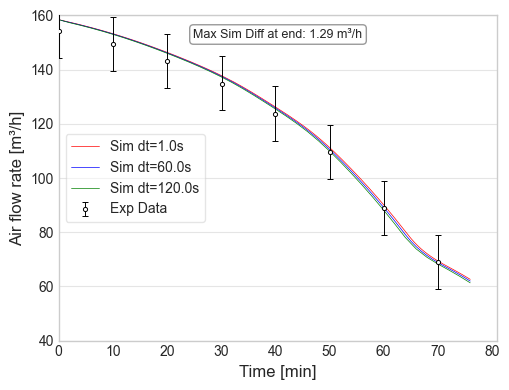


--- Endwerte für: Accumulated Frost Mass ---


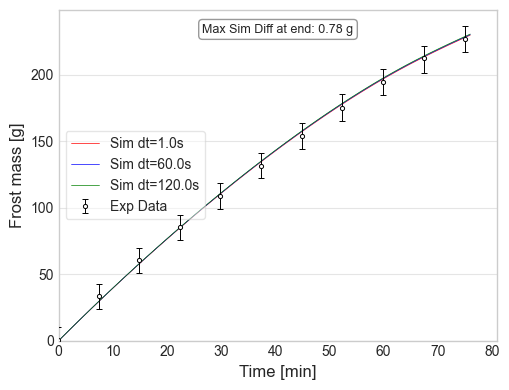

In [65]:
import matplotlib.pyplot as plt
import os
import numpy as np


# Style Settings
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('fast')

EXP_FOLDER_PATH = r"J:\Masterarbeit_Nils_Baumeister\da_Silva_Daten_extrahiert"

exp_file_map = {
    'vol_flow':  'air_flow_rate_all.csv',
    'mass':      'frost_mass_all.csv',
}

plot_specs = [
    # (Col Name, Title, Y-Label, Multiplier, Y-Limits, Exp_Key, EXP_RANGE)
    # Note: EXP_RANGE is (start, end) for the main block. Code now adds index 1 automatically.
    (['vol_flow'], "Volume Flow Rate", "Air flow rate [m³/h]", 1.0, [40, 160], 'vol_flow', (11, 18)),
    (['mass_total'], "Accumulated Frost Mass", "Frost mass [g]", 1000.0, [0, None], 'mass', (10, 20)),
]


def load_and_clean_csv(filepath):
    df = pd.read_csv(filepath, header=None)
    df.columns = ['time', 'value']
    df['time'] = pd.to_numeric(df['time'], errors='coerce')
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    return df.dropna().reset_index(drop=True)

def process_interleaved_triplets(df):
    """Handles Upper/Mean/Lower triplets in the CSV"""
    n = len(df)
    remainder = n % 3
    if remainder != 0:
        df = df.iloc[:-remainder]
    
    upper = df.iloc[0::3].reset_index(drop=True)
    mean  = df.iloc[1::3].reset_index(drop=True)
    lower = df.iloc[2::3].reset_index(drop=True)
    
    x_avg = (upper['time'] + mean['time'] + lower['time']) / 3.0
    y_mean = mean['value']
    err_low = (y_mean - lower['value']).abs()
    err_high = (upper['value'] - y_mean).abs()
    return x_avg, y_mean, err_low, err_high

# --- MAIN PLOT LOOP ---
for col_names, title, y_label, multiplier, y_limits, exp_key, exp_range in plot_specs:
    
    print(f"\n--- Endwerte für: {title} ---")
    
    plt.figure(figsize=(5.2, 4), dpi=100)
    
    # Liste zum Speichern der Endwerte dieser Plot-Instanz
    sim_end_values = []

    # 1. PLOT SIMULATIONS
    if 'results' in locals():
        sorted_keys = sorted(results.keys(), key=lambda x: float(x.split('=')[1][:-1]))
        
        for label in sorted_keys:
            data = results[label]
            df = data['df']
            color = data['color']
            
            for col_name in col_names:
                if col_name in df.columns:
                    # Plot
                    plt.plot(df.index, df[col_name] * multiplier, 
                             label=f"Sim {label}", color=color, linewidth=0.5)
                    
                    # Wert speichern
                    last_val = df[col_name].iloc[-1] * multiplier
                    sim_end_values.append(last_val)


    # ### NEU: Differenz berechnen und oben mittig mit Einheit anzeigen ###
    if sim_end_values:
        max_diff = max(sim_end_values) - min(sim_end_values)
        
        # Einheit aus y_label extrahieren (z.B. aus "Frost mass [g]" -> "g")
        unit = ""
        if "[" in y_label and "]" in y_label:
            unit = y_label.split("[")[1].split("]")[0]
        
        info_text = f"Max Sim Diff at end: {max_diff:.2f} {unit}"
        
        # x=0.5 (Mitte), ha='center' (Zentriert)
        plt.text(0.5, 0.96, info_text, 
                 transform=plt.gca().transAxes,
                 fontsize=9, 
                 horizontalalignment='center', # Wichtig für Zentrierung
                 verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'))

    # 2. PLOT EXPERIMENTAL
    if exp_key in exp_file_map:
        filename = exp_file_map[exp_key]
        full_path = os.path.join(EXP_FOLDER_PATH, filename)
        
        if os.path.exists(full_path):
            try:
                ext_df = load_and_clean_csv(full_path)
                x, y, el, eh = process_interleaved_triplets(ext_df)

                if exp_range is not None:
                    start, end = exp_range
                    
                    # --- MODIFICATION START ---
                    # We create a combined array of indices: 
                    # 1. The specific index [1]
                    # 2. The range [start ... end]
                    
                    # Convert range to list of integers
                    range_indices = np.arange(start, end)
                    
                    # Combine index 1 and the range
                    # Note: If you meant the absolute first item (index 0), change [1] to [0]
                    sel_indices = np.concatenate(([1], range_indices))
                    
                    # Apply selection (assumes x,y etc are numpy arrays or pandas series)
                    x = x[sel_indices]
                    y = y[sel_indices]
                    el = el[sel_indices]
                    eh = eh[sel_indices]
                    # --- MODIFICATION END ---

                plt.errorbar(
                    x, y, yerr=[el, eh],
                    fmt='o', color='black', ecolor='black',
                    markerfacecolor='white', markeredgewidth=0.7, markersize=3.0,
                    capsize=2, elinewidth=0.7, zorder=10,
                    label="Exp Data"
                )
            except Exception as e:
                print(f"  [Error] processing experimental file {filename}: {e}")


    plt.xlabel("Time [min]", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.grid(False) 
    plt.gca().yaxis.grid(True, linestyle='-', alpha=0.5)
    
    if 'DURATION' in locals():
        plt.xlim([0, DURATION + 5])
        
    if y_limits[1] is None:
        plt.ylim(bottom=y_limits[0])
    else:
        plt.ylim(y_limits)

    plt.legend(loc='center left', frameon=True, fancybox=True, framealpha=0.5)
    plt.tight_layout()
    plt.show()